# Laboratory 2.7: Linear Discriminant Analysis

In this practice we will implement one of the simplest but powerfull models, the Linear Discriminant Analysis. We will see how well it performs on a commonly used dataset, the `iris` dataset.

In addition, we will be using the following libraries:
- Data management:
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
- Preprocessing, modelling and scoring:
    - [scikit-learn](https://scikit-learn.org)
- Plotting:
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)
    
### **All the things you need to do are marked by a "TODO" comment nearby. Make sure you *read carefully everything before working* and solve each point before submitting your solution.**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

#### Load data

The Iris dataset is a classic dataset used in machine learning. It contains measurements for iris flowers and their species. This data sets consists of 3 different types of irises’ (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray. You can find a description of this dataset [here](https://en.wikipedia.org/wiki/Iris_flower_data_set).

The task here is to load this dataset into a DataFrame, using pandas, and assign column names for readability.


In [15]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Define column names
cls = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

try:
    dataset = pd.read_csv(url, names=cls)
except Exception:
    # Offline fallback: same data from scikit-learn
    from sklearn.datasets import load_iris
    iris = load_iris()
    dataset = pd.DataFrame(iris.data, columns=cls[:4])
    dataset['Class'] = ['Iris-' + iris.target_names[t] for t in iris.target]
dataset


,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


#### Preprocess data

Divide the dataset into features (X) and target variable (y), then standardize the features for uniformity and encode the target variable for the model. Take into account that the output is not binary anymore, but it has 3 different values.

**Does this affect the error metrics that you can use to evaluate the model? How?**
Sí, con 3 clases ya no sirve accuracy binaria simple. Hay que usar métricas multiclase como accuracy multiclase. La accuracy sigue siendo válida pero hay que interpretar la matriz de confusión por clase

In [16]:
# TODO: Divide the dataset into features (X) and target variable (y), standardize the features, and encode the target variable.
X = dataset.iloc[:, :-1].values  
y = dataset.iloc[:, -1].values

# Standardize the features
sc = StandardScaler()
X = sc.fit_transform(X)
# Encode the target variable using LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

#### Exploratory Data Analysis

Let's try to see if this classification task is easy to perform.

**How would you classify each of the species based on the input features? Which are the most important features?**
En el pairplot vemos que iris setosa es perfectamente separable usando petal-length y petal-width. Sin embargo, las dos otras se solapan bastante aunque sí son mejor diferenciables por petal length o petal width.

Estas dos últimas features son las más importantes ya que maximizan la separación entre clases

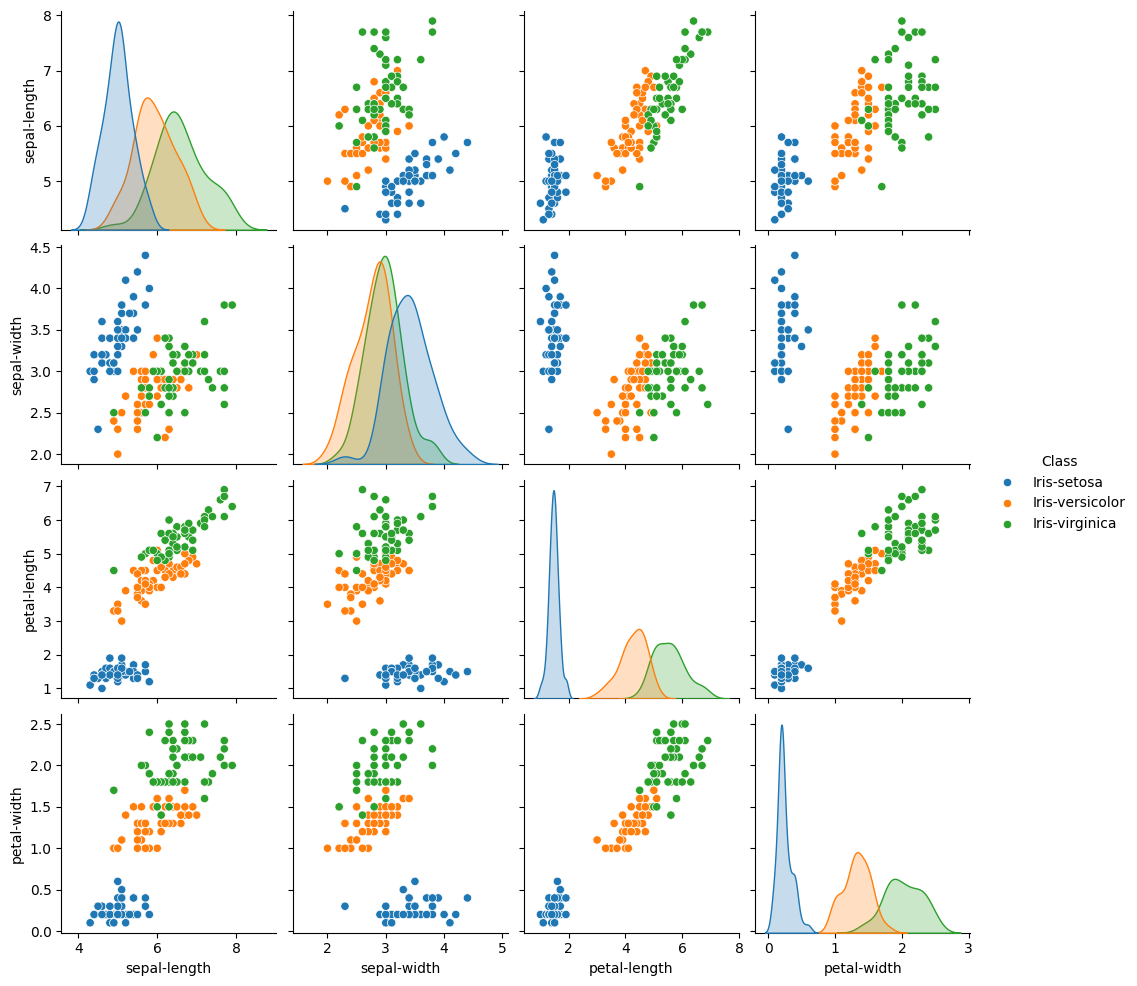

In [17]:
# TODO: Create a pair plot to visualize relationships between different features and species.
import seaborn as sns
df_plot = dataset.copy()
sns.pairplot(df_plot, hue='Class')
plt.show()

#### Split between training and test

In [18]:
# TODO: Split the dataset into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Discriminant Analysis model

[LDA algorithm](https://en.wikipedia.org/wiki/Linear_discriminant_analysis)

In this section, we will implement the `LinearDiscriminant` class. This is a The primary goal of its `fit` function is to learn the most discriminative features between different classes. This involves a series of steps which we will break down below.

#### Understanding the Fit Function

1. **Calculating Class Mean Vectors**:
   Each class in the dataset has a mean vector calculated as the mean of the features for samples of that particular class. This mean helps in understanding the average feature values of each class.

2. **Computing Scatter Matrices**:
   The within-class scatter matrix (`S_W`) and the between-class scatter matrix (`S_B`) are two key components in LDA. `S_W` is computed as the sum of scatter matrices for each class, where the scatter matrix of each class is the matrix of variances and covariances of the features within that class. `S_B`, on the other hand, captures the separation between different classes.

3. **Solving the Eigenvalue Problem**:
   The core of LDA lies in solving the eigenvalue problem for the matrix `S_W^-1 * S_B`. This step involves finding the eigenvalues and corresponding eigenvectors for this matrix product. The eigenvectors represent the directions that maximize the class separability, while the eigenvalues are a measure of how much of the variance in the data is captured by these directions.


4. **Storing Class Means in the Transformed Space**:
   Once we have our linear discriminants (the selected eigenvectors), it's essential to project the mean vectors of each class onto this new lower-dimensional space. These transformed means will be used later in the classification process. They represent the average position of each class in the space defined by the linear discriminants.

5. **Calculating Class Priors**:
   Class priors represent the probability of each class occurring in the dataset. They are estimated simply as the proportion of instances of each class in the training set. These priors are used in the classification stage to weigh the decision based on the frequency of each class. In scenarios where classes are imbalanced, this step becomes crucial for a fair assessment during prediction.


##### Focusing on the Eigenvalue Problem

- The eigenvalue problem is a fundamental aspect of LDA, where we aim to find the linear combinations of the original features that best separate the classes. These linear combinations are the eigenvectors of `S_W^-1 * S_B`.
- By solving this problem, we obtain a set of eigenvalues and their corresponding eigenvectors. The eigenvalues signify the magnitude of variance captured by their respective eigenvectors.
- To find the most discriminative features, we sort these eigenpairs (eigenvalue-eigenvector pairs) in descending order of eigenvalues. This sorting ensures that the eigenvectors with the highest eigenvalues (i.e., those that capture the most variance) are selected for transforming the dataset.
- Typically, we select the top `n` eigenvectors as our linear discriminants, where `n` is the number of components we wish to keep.

#### Understanding the Transform function

1. **Projection onto New Feature Space**
The core operation in the transform method is a matrix multiplication. Each data point (a vector) in the dataset is projected onto the new feature space using the linear discriminants (eigenvectors) obtained from the eigenvalue problem solved in the fit method.
Mathematically, if X is your data matrix (with samples as rows and features as columns) and W is the matrix of selected linear discriminants (eigenvectors), the transformation is performed as X_transformed = X * W.
This operation transforms the data into a new space where the axes are the linear discriminants, and the dimensions are reduced to the number of selected linear discriminants.

2. **Dimensionality Reduction**
The LDA aims to reduce the number of dimensions while retaining as much class-discriminatory information as possible. The transform method effectively reduces the dimensionality of the data from the original number of features to the number of linear discriminants chosen (typically the number of classes minus one). This dimensionality reduction is beneficial for visualizing data, reducing computational cost, and potentially improving the performance of classifiers applied to the transformed data.

#### Understanding the Predict Function

1. **Projecting New Data**:
   - The first step in prediction is to transform the new data points into the same lower-dimensional space as the training data. This is done using the same linear discriminants (eigenvectors) obtained during the `fit` process.
   - Mathematically, this involves multiplying the new data points by the linear discriminants, similar to the `transform` method.

2. **Classifying Based on Proximity to Class Means**:
   - Once the data is in the lower-dimensional space, the classification is based on the proximity of each transformed data point to the mean of each class in this space.
   - The assumption in LDA is that data points are more likely to belong to the class whose mean is closest to them in the transformed space.

3. **Calculating Distances and Making Predictions**:
   - The distances between each transformed data point and the means of each class are calculated. The class whose mean is closest to the data point is considered the predicted class.
   - This can be achieved by using a distance metric, like the Euclidean distance, to measure the closeness between data points and class means.


In [20]:

# Import the LDA model here
import sys
import os
sys.path.insert(0, os.path.abspath('..'))


from src.LDA_model import LinearDiscriminant

In [21]:
# Apply Linear Discriminant Analysis
lda = LinearDiscriminant(n_components=2)
X_train_transformed = lda.fit_transform(X_train, y_train)
X_test_transformed = lda.transform(X_test)

Once LDA is trained, we can check the weight associated to each input variable for each LDA component to see which inputs have more influence in the LDA transformations.

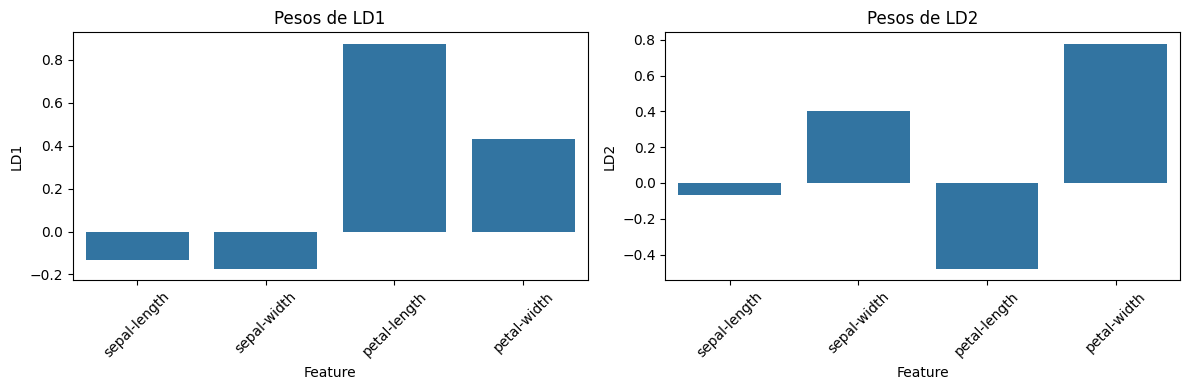

In [22]:
# Extract the weights (coefficients) of the model
lda_weights = lda.weights

# Create a dataframe with lda_weights where each column is one LDA component
weights_df = pd.DataFrame(lda_weights, columns=['LD1', 'LD2'])

# Add feature names
weights_df['Feature'] = cls[:-1]

# Create a seaborn barplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['LD1', 'LD2']):
    sns.barplot(data=weights_df, x='Feature', y=col, ax=axes[i])
    axes[i].set_title(f'Pesos de {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

- Which inputs are most important for the LDA components?
> Viendo el barplot:
--> Para LD1 petal-length y petal-width tienen pesos más grandes (separan bien las 3 clases)
-->Para LD2: sepal width contribuye más.

Visualizing the data after applying LDA can provide insights into how well the classes are separated in the reduced feature space. 

Here we are using a scatter plot to see how the model has transformed the input features to make the output linear separable.

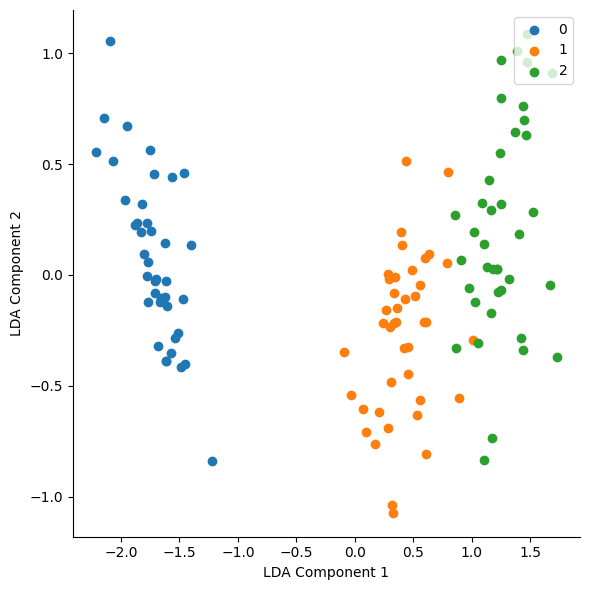

In [23]:
tmp_Df = pd.DataFrame(X_train_transformed, columns=['LDA Component 1','LDA Component 2'])
tmp_Df['Class']=y_train

sns.FacetGrid(tmp_Df, hue ="Class", height = 6).map(plt.scatter, 'LDA Component 1', 'LDA Component 2')
plt.legend(loc='upper right')
plt.show()

### Evaluate the model

Let's check how good the model is predicting the flower species.  

Accuracy: 0.95


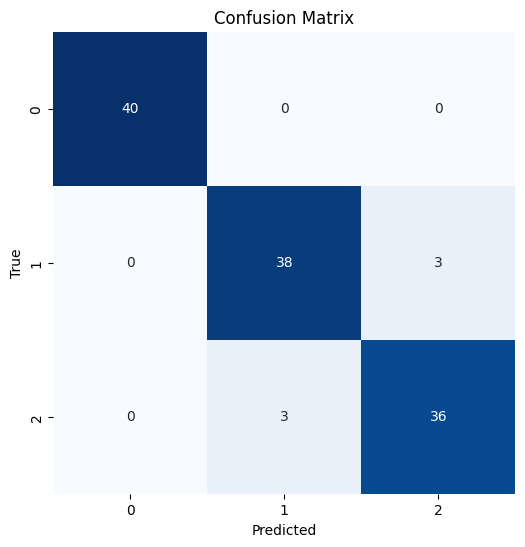

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_train = lda.predict(X_train)
accuracy = accuracy_score(y_train, y_pred_train)
conf_m = confusion_matrix(y_train, y_pred_train)

#Display the accuracy
print(f'Accuracy: {accuracy:.2f}')

#Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### Sensitivity Analysis
- Train the model with different values of `n_components`. Which is the optimal value of `n_components`? Use the `cross_validation` function created in Lab 2.6 to answer this question.
El máximo de componentes en LDA es min(n_clases-1,n_features). min(2,4)= 2.
Por tanto es probar 1 vs 2 componentes con cross validation. Los resultados muestran que 1 componente es suficiente y mejor que 2. Tiene sentido porque iris-setosa es perfectamente separable del resto con un solo discriminante lineal. Añadir LD2 introduce ruido adicional que perjudica ligeramente la generalización.

In [28]:
# TODO: Use cross_validation to obtain the optimal value of n_components
from sklearn.model_selection import StratifiedKFold

def cross_validation_lda(X, y, n_components, n_folds=5):
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    accuracies = []
    for train_idx, val_idx in kf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        model = LinearDiscriminant(n_components=n_components)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        accuracies.append(accuracy_score(y_val, y_pred))
    return np.mean(accuracies)

for nc in [1, 2]:
    acc = cross_validation_lda(X, y, n_components=nc)
    print(f"n_components={nc} → CV Accuracy: {acc:.4f}")

n_components=1 → CV Accuracy: 0.9867
n_components=2 → CV Accuracy: 0.9667
